# Road Damage Detection - YOLOv11 Training Notebook (Roboflow Dataset)

This notebook downloads the full dataset from Roboflow, explores it, applies preprocessing/augmentation for higher accuracy, trains YOLOv11, evaluates it, and runs inference.


## 1. Install Dependencies

In [1]:
!pip install ultralytics roboflow -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 106.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.4 MB/s eta 0:00:00


## 2. Download the Dataset from Roboflow

In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="xcDJdDJpIdytumuUX8pM")
project = rf.workspace("xjta").project("road-damage-aoapj")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to road-damage-1 in yolov11:: 100%|██████████| 4008/4008 [00:02<00:00, 1892.22it/s]


In [3]:
import os

DATASET_DIR = dataset.location
print("Dataset location:", DATASET_DIR)
print(os.listdir(DATASET_DIR))


Dataset location: /content/road-damage-1
['train', 'valid', 'test', 'data.yaml', 'README.dataset.txt', 'README.roboflow.txt']


## 3. Inspect data.yaml

In [4]:
import yaml

yaml_path = os.path.join(DATASET_DIR, "data.yaml")
with open(yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

print(data_config)

CLASS_NAMES = data_config["names"]
NUM_CLASSES = data_config["nc"]


{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['Cracks', 'Manholes', 'Potholes'], 'roboflow': {'workspace': 'xjta', 'project': 'road-damage-aoapj', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/xjta/road-damage-aoapj/dataset/1'}}


## 4. Dataset Overview

In [5]:
def count_images(split_dir):
    if not os.path.exists(split_dir):
        return 0
    return len([f for f in os.listdir(split_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])

for split in ["train", "valid", "test"]:
    img_dir = os.path.join(DATASET_DIR, split, "images")
    print(f"{split}: {count_images(img_dir)} images")


train: 1397 images
valid: 400 images
test: 201 images


## 5. Exploratory Data Analysis

In [6]:
from collections import Counter

def count_classes(labels_dir):
    counter = Counter()
    if not os.path.exists(labels_dir):
        return counter
    for fname in os.listdir(labels_dir):
        if not fname.endswith(".txt"):
            continue
        with open(os.path.join(labels_dir, fname), "r") as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counter[int(parts[0])] += 1
    return counter

train_labels_dir = os.path.join(DATASET_DIR, "train", "labels")
class_counts = count_classes(train_labels_dir)

for class_id, count in sorted(class_counts.items()):
    name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f"class_{class_id}"
    print(f"{name}: {count}")


Cracks: 1763
Manholes: 668
Potholes: 871


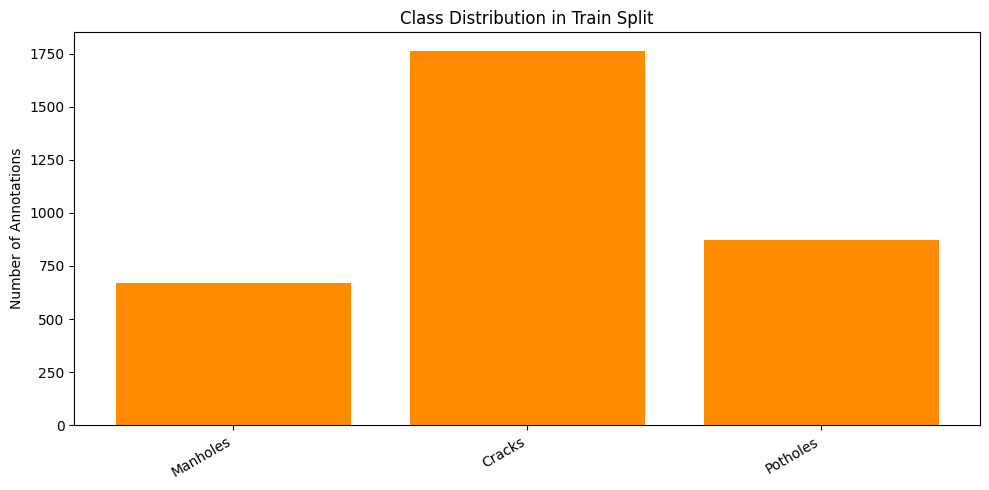

In [7]:
import matplotlib.pyplot as plt

labels = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else str(i) for i in class_counts.keys()]
values = list(class_counts.values())

plt.figure(figsize=(10, 5))
plt.bar(labels, values, color="darkorange")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of Annotations")
plt.title("Class Distribution in Train Split")
plt.tight_layout()
plt.show()


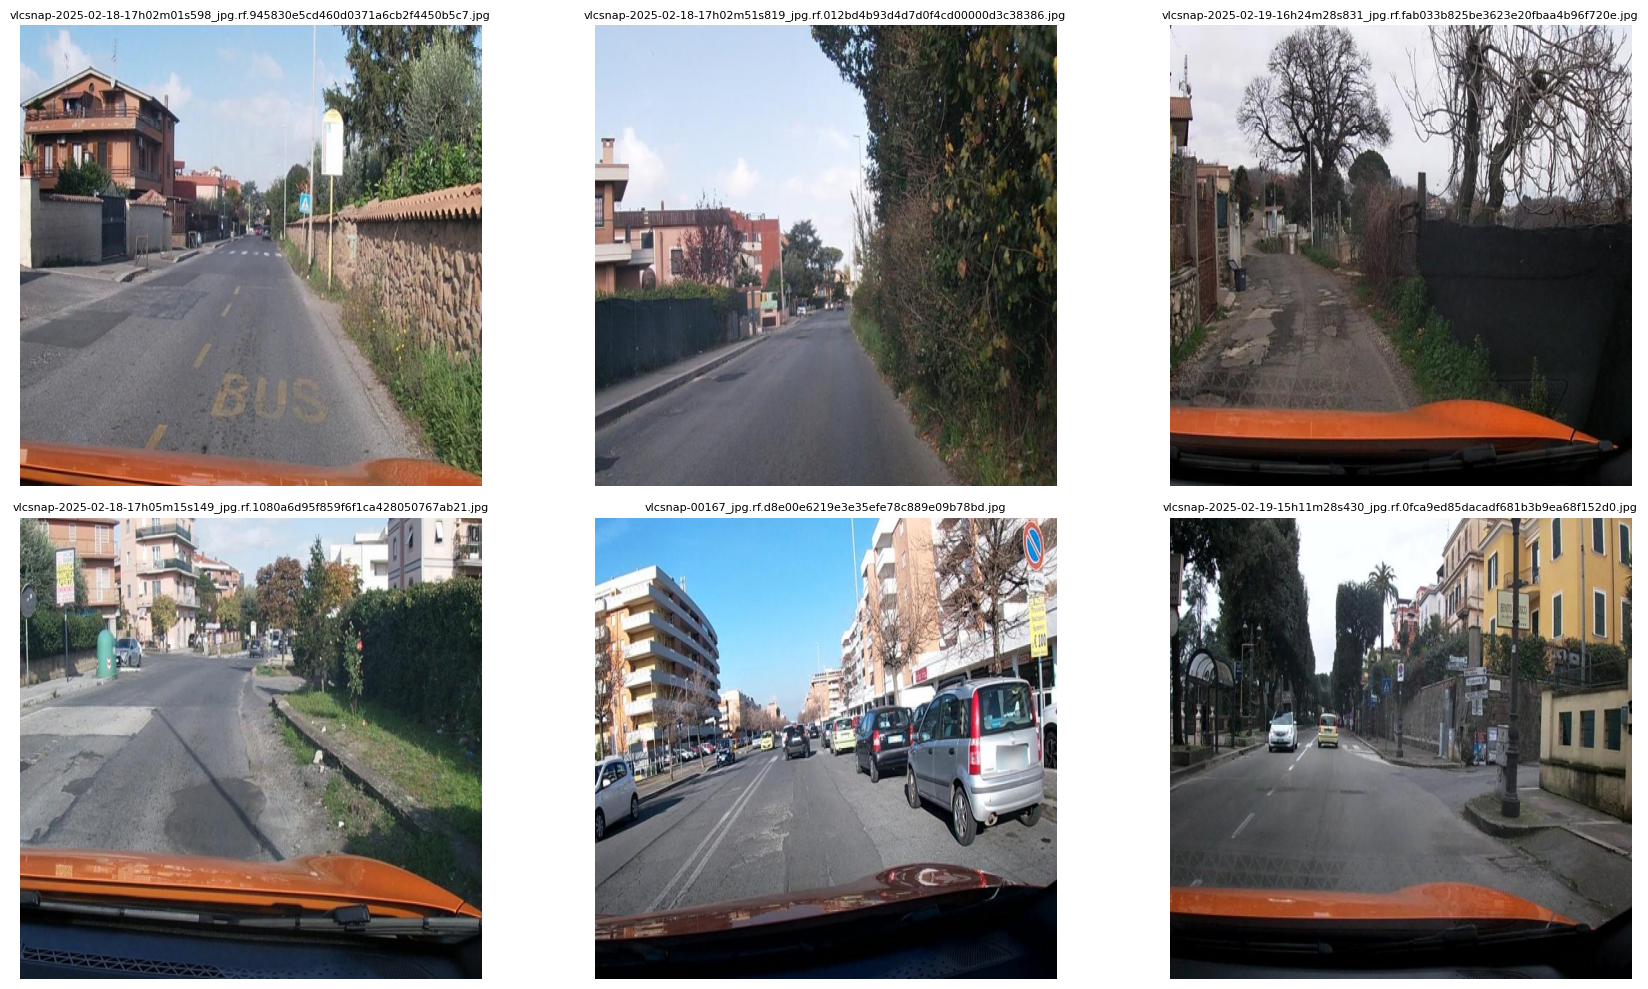

In [8]:
import cv2
import random

def draw_boxes(image_path, label_path, class_names):
    img = cv2.imread(image_path)
    h, w = img.shape[:2]
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                class_id, xc, yc, bw, bh = parts
                class_id = int(class_id)
                xc, yc, bw, bh = float(xc), float(yc), float(bw), float(bh)
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                label = class_names[class_id] if class_id < len(class_names) else str(class_id)
                cv2.putText(img, label, (x1, max(y1 - 5, 0)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

train_images_dir = os.path.join(DATASET_DIR, "train", "images")
image_files = os.listdir(train_images_dir)
sample_files = random.sample(image_files, min(6, len(image_files)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, fname in zip(axes.flatten(), sample_files):
    img_path = os.path.join(train_images_dir, fname)
    label_path = os.path.join(train_labels_dir, os.path.splitext(fname)[0] + ".txt")
    ax.imshow(draw_boxes(img_path, label_path, CLASS_NAMES))
    ax.set_title(fname, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Data Quality Check

Detect corrupt or unreadable images and empty label files before training.

In [9]:
def check_dataset_quality(images_dir, labels_dir):
    corrupt = []
    empty_labels = []
    missing_labels = []
    for fname in os.listdir(images_dir):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        img_path = os.path.join(images_dir, fname)
        img = cv2.imread(img_path)
        if img is None:
            corrupt.append(fname)

        label_path = os.path.join(labels_dir, os.path.splitext(fname)[0] + ".txt")
        if not os.path.exists(label_path):
            missing_labels.append(fname)
        elif os.path.getsize(label_path) == 0:
            empty_labels.append(fname)
    return corrupt, empty_labels, missing_labels

corrupt, empty_labels, missing_labels = check_dataset_quality(train_images_dir, train_labels_dir)
print("Corrupt images:", len(corrupt))
print("Empty label files:", len(empty_labels))
print("Missing label files:", len(missing_labels))


Corrupt images: 0
Empty label files: 0
Missing label files: 0


## 7. Train YOLOv11

Using a larger backbone, higher resolution, augmentation, and a longer training schedule with early stopping to push accuracy up.

In [10]:
from ultralytics import YOLO

model = YOLO("yolo11s.pt")

results = model.train(
    data=yaml_path,
    epochs=150,
    imgsz=832,
    batch=16,
    patience=25,
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    mosaic=1.0,
    mixup=0.15,
    close_mosaic=10,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    fliplr=0.5,
    flipud=0.0,
    label_smoothing=0.05,
    project="/content/runs",
    name="road_damage_yolo11"
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.4.99 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/road-damage-1/data.yaml, degrees=5.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=Fals

## 8. Evaluate the Model

In [11]:
metrics = model.val(data=yaml_path, split="test", imgsz=832, augment=True)
print(metrics)


Ultralytics 8.4.99 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,413,961 parameters, 0 gradients, 21.3 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 20.9±13.6 MB/s, size: 62.4 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/road-damage-1/test/labels... 201 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 201/201 699.2it/s 0.3s
val: New cache created: /content/road-damage-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.1it/s 11.5s
                   all        201        457       0.55      0.589      0.555      0.248
                Cracks        137        251      0.406      0.486      0.399       0.17
              Manholes         75         98      0.722      0.847      0.818      0.407
     

## 9. Run Inference on Sample Test Images

In [ ]:
test_images_dir = os.path.join(DATASET_DIR, "test", "images")
test_images = os.listdir(test_images_dir)
sample_test = random.sample(test_images, min(6, len(test_images)))

results = model.predict(
    source=[os.path.join(test_images_dir, f) for f in sample_test],
    imgsz=832,
    conf=0.25,
    augment=True,
    save=True
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, r in zip(axes.flatten(), results):
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.tight_layout()
plt.show()


## 10. Save Trained Weights

In [13]:
best_weights = "/content/runs/road_damage_yolo11/weights/best.pt"
print("Best weights saved at:", best_weights)


Best weights saved at: /content/runs/road_damage_yolo11/weights/best.pt
